In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/ai4i-dataset/ai4i2020.csv


In [1]:
import pandas as pd
df=pd.read_csv('/kaggle/input/datasets/gauravrawat99/ai4i-dataset/ai4i2020.csv')
df.columns = (
    df.columns
      .str.replace('[', '', regex=False)
      .str.replace(']', '', regex=False)
      .str.replace(' ', '_')
      .str.replace('/', '_')
)
df

,UDI,Product_ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UDI                    10000 non-null  int64  
 1   Product_ID             10000 non-null  object 
 2   Type                   10000 non-null  object 
 3   Air_temperature_K      10000 non-null  float64
 4   Process_temperature_K  10000 non-null  float64
 5   Rotational_speed_rpm   10000 non-null  int64  
 6   Torque_Nm              10000 non-null  float64
 7   Tool_wear_min          10000 non-null  int64  
 8   Machine_failure        10000 non-null  int64  
 9   TWF                    10000 non-null  int64  
 10  HDF                    10000 non-null  int64  
 11  PWF                    10000 non-null  int64  
 12  OSF                    10000 non-null  int64  
 13  RNF                    10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ M

In [5]:
df.describe(include='all')

,UDI,Product_ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [6]:
df.value_counts('TWF')

TWF
0    9954
1      46
Name: count, dtype: int64

Machine failure count by quality type
Type
L    235
M     83
H     21
Name: Machine_failure, dtype: int64


Text(0.5, 1.0, 'Machine failure by Quality Type')

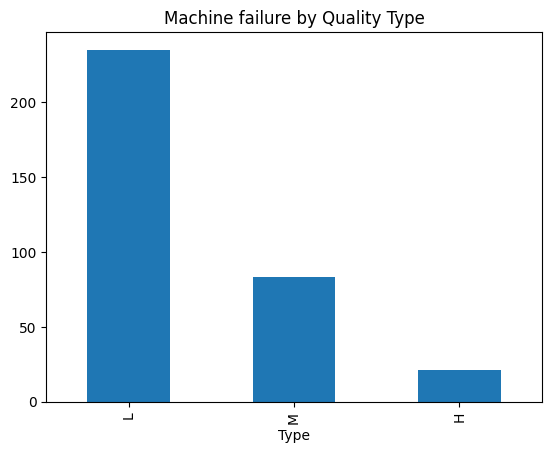

In [7]:
machine_failure_by_type=df[df['Machine_failure'] == 1].groupby('Type')['Machine_failure'].count().sort_values(ascending=False)
print('Machine failure count by quality type')
print(machine_failure_by_type)

#plot
import matplotlib.pyplot as plt
machine_failure_by_type.plot(kind='bar')
plt.title("Machine failure by Quality Type")

Machine Failure type's count:
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


<Axes: title={'center': 'Machine Failure rate by Type count'}>

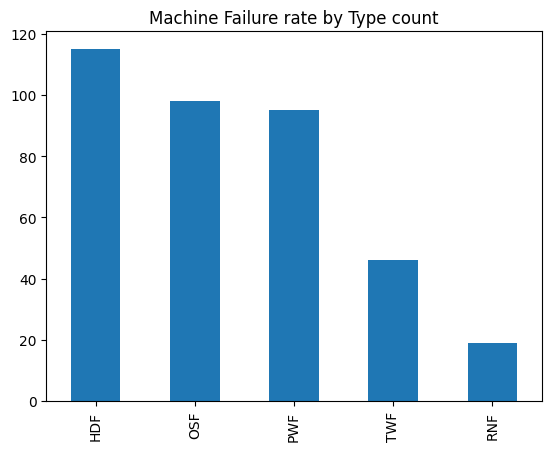

In [8]:
mf_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Machine Failure type's count:")
smf=df[mf_cols].sum().sort_values(ascending=False) #smf=Sum machine failure
print(smf)
plt.title("Machine Failure rate by Type count")
smf.plot(kind='bar')

   Type MF_type  Count
0     H     TWF      7
1     L     TWF     25
2     M     TWF     14
3     H     HDF      8
4     L     HDF     76
5     M     HDF     31
6     H     PWF      5
7     L     PWF     59
8     M     PWF     31
9     H     OSF      2
10    L     OSF     87
11    M     OSF      9
12    H     RNF      0
13    L     RNF      1
14    M     RNF      0


Text(0.5, 1.0, 'Machine failure type with Quality type')

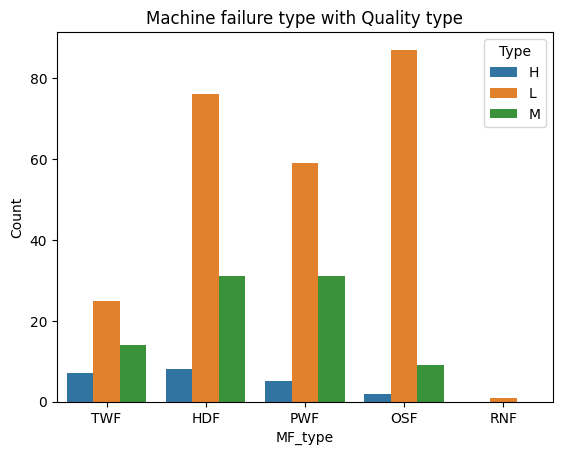

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

mf_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
smf_type=df[df['Machine_failure'] == 1].groupby('Type')[mf_cols].sum().reset_index()

#Convert wide --> long (very small step)
plot_df=smf_type.melt(id_vars='Type', var_name='MF_type', value_name='Count')
print(plot_df)

#Plot
sns.barplot(data=plot_df, x='MF_type', y='Count', hue='Type')
plt.title('Machine failure type with Quality type')

In [2]:
#Feature engineering cols
import numpy as np

# 1) Temperature difference (used in HDF rule)
df['temp_diff'] = df['Process_temperature_K'] - df['Air_temperature_K']

# 2) Power in Watts (used in PWF rule)
df['power'] = df['Rotational_speed_rpm'] * 2 * np.pi/60 * df['Torque_Nm']

# 3) Wear–Torque interaction (used in OSF rule)
df['wear_torque'] = df['Tool_wear_min'] * df['Torque_Nm']

# 4) Wear–Speed interaction (useful hidden pattern)
df['wear_speed'] = df['Tool_wear_min'] * df['Rotational_speed_rpm']

# 5) Torque per rpm (stress indicator)
df['torque_rpm_ratio'] = df['Torque_Nm'] / df['Rotational_speed_rpm']

# 6) Encode quality effect numerically
df['Type_num'] = df['Type'].map({'L':1, 'M':2, 'H':3})

# 7) Overstrain limit based on Type (direct OSF logic)
df['strain_limit'] = df['Type'].map({'L':11000, 'M':12000, 'H':13000})
df['strain_ratio'] = df['wear_torque'] / df['strain_limit']

df['mech_stress'] = df['Torque_Nm'] * df['Rotational_speed_rpm']
df['thermal_stress'] = df['temp_diff'] * df['Rotational_speed_rpm']
df['torque_type_ratio'] = df['Torque_Nm'] / df['Type_num']
df['stress_acc_proxy'] = (
    df['Torque_Nm'] * df['Rotational_speed_rpm'] * df['Tool_wear_min']
)
df['cooling_efficiency'] = df['temp_diff'] / df['Air_temperature_K']
df['speed_temp'] = df['Rotational_speed_rpm'] * df['Process_temperature_K']
df['torque_sq'] = df['Torque_Nm'] ** 2
df['speed_sq'] = df['Rotational_speed_rpm'] ** 2
df['temp_per_speed'] = df['Process_temperature_K'] / df['Rotational_speed_rpm']
df['torque_per_temp'] = df['Torque_Nm'] / df['Process_temperature_K']
df['hdf_margin'] = df['temp_diff'] - 8.6
df['pwf_low_margin'] = df['power'] - 3500
df['pwf_high_margin'] = 9000 - df['power']

## Model Training

### Task 1: Classifier for machine failure prediction

In [4]:
drop_cols=['UDI', 'Product_ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine_failure']
cat_cols=['Type']

#Training Catboost Classifier for machine failure of 0 or 1
X_cls=df.drop(columns=drop_cols, axis=1)
y_cls=df['Machine_failure']

print('Classification task of "Will Machine fail?"')
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, random_state=42)

train_pool=Pool(X_train, y_train, cat_features=cat_cols)
test_pool=Pool(X_test, y_test, cat_features=cat_cols)

model_cls=CatBoostClassifier(iterations=5000, depth=6, learning_rate=0.03, loss_function='Logloss', eval_metric='F1', random_state=42, verbose=500).fit(train_pool, eval_set=test_pool)

Classification task of "Will Machine fail?"
0:	learn: 0.0569395	test: 0.0519481	best: 0.0519481 (0)	total: 72.2ms	remaining: 6m 1s
500:	learn: 0.9570313	test: 0.8571429	best: 0.8571429 (233)	total: 5.09s	remaining: 45.7s
1000:	learn: 0.9809160	test: 0.8461538	best: 0.8636364 (587)	total: 10.1s	remaining: 40.4s
1500:	learn: 0.9924528	test: 0.8461538	best: 0.8636364 (587)	total: 15s	remaining: 35s
2000:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 19.9s	remaining: 29.9s
2500:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 24.8s	remaining: 24.8s
3000:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 29.7s	remaining: 19.8s
3500:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 34.5s	remaining: 14.8s
4000:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 39.3s	remaining: 9.82s
4500:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 (587)	total: 43.8s	remaining: 4.86s
4999:	learn: 1.0000000	test: 0.8549618	best: 0.8636364 

In [6]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred=model_cls.predict(test_pool)

probs = model_cls.predict_proba(test_pool)[:,1]
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    y_pred_t = (probs > t).astype(int)
    # print(t)
    print(f'Classification Report for CatboostClassifier with threshold {t}\n',classification_report(y_test, y_pred_t))
    print(f'Confusion Matrix for CatboostClassifier with threshold {t}:\n', confusion_matrix(y_test, y_pred_t))
# print('Confusion Matrix for CatboostClassifier:\n', confusion_matrix(y_test, y_pred))
# print('Classification Report for CatboostClassifier:\n', classification_report(y_test, y_pred))
# print('ROC-AUC score for CatboostClassifier: ', roc_auc_score(y_test, y_pred))

Classification Report for CatboostClassifier with threshold 0.2
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2428
           1       0.84      0.82      0.83        72

    accuracy                           0.99      2500
   macro avg       0.92      0.91      0.91      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix for CatboostClassifier with threshold 0.2:
 [[2417   11]
 [  13   59]]
Classification Report for CatboostClassifier with threshold 0.25
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2428
           1       0.87      0.82      0.84        72

    accuracy                           0.99      2500
   macro avg       0.93      0.91      0.92      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix for CatboostClassifier with threshold 0.25:
 [[2419    9]
 [  13   59]]
Classification Report for CatboostClas

In [7]:
#Train XGBoost classifier for same problem
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

drop_cols=['UDI', 'Product_ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine_failure']
cat_cols=['Type']

X_cls=df.drop(columns=drop_cols, axis=1)
y_cls=df['Machine_failure']

#Encoding of X_cls
X_encoded=pd.get_dummies(X_cls)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_cls, random_state=42)

param_grid={'n_estimators':[50,100,150,200], 'max_depth':[3,4,5,6]}
grid_search_xgb=GridSearchCV(XGBClassifier(n_jobs=-1), param_grid=param_grid, cv=5).fit(X_train, y_train)

grid_search_xgb_pred=grid_search_xgb.predict(X_test)

probs = grid_search_xgb.predict_proba(X_test)[:,1]
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    y_pred_t = (probs > t).astype(int)
    # print(t)
    print(f'Classification Report for XGBClassifier with threshold {t}\n',classification_report(y_test, y_pred_t))
    print(f'Confusion Matrix for XGBClassifier with threshold {t}:\n', confusion_matrix(y_test, y_pred_t))

print("Best params for XGBClassifier: ", grid_search_xgb.best_params_)
# print('Confusion Matrix for XGBClassifier:\n', confusion_matrix(y_test, grid_search_xgb_pred))
# print('Classification Report for XGBClassifier:\n', classification_report(y_test, grid_search_xgb_pred))
# print('ROC-AUC score for XGBClassifier: ', roc_auc_score(y_test, grid_search_xgb_pred))

Classification Report for XGBClassifier with threshold 0.2
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2428
           1       0.81      0.81      0.81        72

    accuracy                           0.99      2500
   macro avg       0.90      0.90      0.90      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix for XGBClassifier with threshold 0.2:
 [[2414   14]
 [  14   58]]
Classification Report for XGBClassifier with threshold 0.25
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2428
           1       0.84      0.81      0.82        72

    accuracy                           0.99      2500
   macro avg       0.92      0.90      0.91      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix for XGBClassifier with threshold 0.25:
 [[2417   11]
 [  14   58]]
Classification Report for XGBClassifier with threshold 0.3

##### CatBoostClassifier showed best recall as result with thrshold of 0.2 so saving that model

In [8]:
#Saving results of CatBoostClassifier with threshold 0.2
import joblib
import json
import os
import numpy as np
from catboost import CatBoostClassifier

# ── Output directory (Kaggle writes here) ──────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save CatBoost model in native format (.cbm) ────────────────────────────
model_cls.save_model(os.path.join(OUTPUT_DIR, "model.cbm"))
print(" model.cbm saved")

# ── 2. Save feature column names & order (what X_cls looked like) ─────────────
feature_cols = list(X_cls.columns)   # preserves exact order used during training
joblib.dump(feature_cols, os.path.join(OUTPUT_DIR, "feature_cols.pkl"))
print(f" feature_cols.pkl saved → {feature_cols}")

# ── 3. Save config (threshold + categorical columns) ──────────────────────────
config = {
    "best_threshold": 0.2,
    "cat_features": ["Type"],                        # used in Pool()
    "target": "Machine failure",
    "model_type": "CatBoostClassifier",
    "drop_cols_during_training": [                   # UI will collect these as inputs
        "UDI", "Product ID", "TWF", "HDF",
        "PWF", "OSF", "RNF", "Machine failure"
    ],
    "type_categories": sorted(df["Type"].unique().tolist()),   # e.g. ['H','L','M']
    "numeric_features": [c for c in X_cls.columns if c != "Type"],
    "feature_ranges": {
        col: {
            "min": float(df[col].min()),
            "max": float(df[col].max()),
            "mean": float(df[col].mean())
        }
        for col in X_cls.select_dtypes(include=[np.number]).columns
    }
}
with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)
print(" config.json saved")

# ── 4. Save label encoder for 'Type' column (for safe UI → model mapping) ──────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df["Type"])
joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoders.pkl"))
print(f" label_encoders.pkl saved → classes: {list(le.classes_)}")

# ── Verification: reload & quick sanity check ──────────────────────────────────
print("\n── Sanity check ──")
_model  = CatBoostClassifier()
_model.load_model(os.path.join(OUTPUT_DIR, "model.cbm"))
_cols   = joblib.load(os.path.join(OUTPUT_DIR, "feature_cols.pkl"))
_cfg    = json.load(open(os.path.join(OUTPUT_DIR, "config.json")))
_le     = joblib.load(os.path.join(OUTPUT_DIR, "label_encoders.pkl"))

_pool   = test_pool                          # reuse your existing test pool
_probs  = _model.predict_proba(_pool)[:, 1]
_preds  = (_probs > _cfg["best_threshold"]).astype(int)

from sklearn.metrics import f1_score
print(f"Reloaded model F1 @ threshold {_cfg['best_threshold']}: "
      f"{f1_score(y_test, _preds):.4f}")
print(f"Feature columns  : {_cols}")
print(f"Type categories  : {_cfg['type_categories']}")
print("\n All artifacts verified — ready for Streamlit UI")

 model.cbm saved
 feature_cols.pkl saved → ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'power', 'wear_torque', 'wear_speed', 'torque_rpm_ratio', 'Type_num', 'strain_limit', 'strain_ratio', 'mech_stress', 'thermal_stress', 'torque_type_ratio', 'stress_acc_proxy', 'cooling_efficiency', 'speed_temp', 'torque_sq', 'speed_sq', 'temp_per_speed', 'torque_per_temp', 'hdf_margin', 'pwf_low_margin', 'pwf_high_margin']
 config.json saved
 label_encoders.pkl saved → classes: ['H', 'L', 'M']

── Sanity check ──
Reloaded model F1 @ threshold 0.2: 0.8310
Feature columns  : ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'temp_diff', 'power', 'wear_torque', 'wear_speed', 'torque_rpm_ratio', 'Type_num', 'strain_limit', 'strain_ratio', 'mech_stress', 'thermal_stress', 'torque_type_ratio', 'stress_acc_proxy', 'cooling_efficiency', 'speed_temp', 'torque_sq', 'speed_sq'

### Task 2: Regression task: Tool wear [min] (degradation modeling): How much tool life left?

In [10]:
# drop_cols=['Product_ID','Tool_wear_min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'wear_torque', 'Machine_failure', 'wear_speed', 'strain_ratio', 'stress_acc_proxy', 'hdf_margin',
#            'pwf_low_margin','pwf_high_margin', 'Type'] #Dropping Type too as i haved encoded that to numeric

# X_wear=df.drop(columns=drop_cols, axis=1)
X_wear = df[[
    'UDI',                  # strongest signal — monotonic time proxy for wear
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Type_num',             # encoded quality type (L/M/H → 1/2/3)
    'strain_limit',         # type-based threshold (11k/12k/13k) — no leakage
    'temp_diff',            # process - air temp
    'power',                # rpm × torque physics — no leakage here
    'torque_rpm_ratio',     # stress indicator
    'mech_stress',          # torque × rpm
    'thermal_stress',       # temp_diff × rpm
    'torque_type_ratio',    # torque / type_num
    'cooling_efficiency',   # temp_diff / air_temp
    'speed_temp',           # rpm × process_temp
    'torque_sq',
    'speed_sq',
    'temp_per_speed',
    'torque_per_temp',
]]
y_wear=df['Tool_wear_min']

In [41]:
from scipy.stats import skew
skew=X_wear.skew()
skew

UDI                      0.000000
Air_temperature_K        0.114274
Process_temperature_K    0.015027
Rotational_speed_rpm     1.993171
Torque_Nm               -0.009517
Type_num                 0.993856
strain_limit             0.993856
temp_diff               -0.072484
power                    0.008257
torque_rpm_ratio         0.165948
mech_stress              0.008257
thermal_stress           1.028399
torque_type_ratio        0.246431
cooling_efficiency      -0.082790
speed_temp               1.988353
torque_sq                0.722166
speed_sq                 2.940812
temp_per_speed          -0.795188
torque_per_temp         -0.009342
dtype: float64

In [34]:
#CatBoost training
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_wear, y_wear, random_state=42)

model_cbr_wear=CatBoostRegressor(iterations=5000, learning_rate=0.02, depth=6, l2_leaf_reg=5, loss_function='RMSE', eval_metric='RMSE', random_state=42, verbose=500).fit(X_train, y_train)

model_cbr_wear_pred=model_cbr_wear.predict(X_test)
print("CatBoostRegressor results")
print("MAE: ", mean_absolute_error(y_test, model_cbr_wear_pred))
print("R2 score: ", r2_score(y_test, model_cbr_wear_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_cbr_wear_pred)))

0:	learn: 63.1932523	total: 5ms	remaining: 25s
500:	learn: 58.8916803	total: 1.8s	remaining: 16.2s
1000:	learn: 54.3132322	total: 3.65s	remaining: 14.6s
1500:	learn: 51.0188379	total: 5.47s	remaining: 12.8s
2000:	learn: 48.4841821	total: 7.28s	remaining: 10.9s
2500:	learn: 46.1858184	total: 9.08s	remaining: 9.07s
3000:	learn: 44.2890410	total: 10.9s	remaining: 7.26s
3500:	learn: 42.5678821	total: 12.8s	remaining: 5.46s
4000:	learn: 40.9907527	total: 14.6s	remaining: 3.64s
4500:	learn: 39.4989881	total: 16.4s	remaining: 1.82s
4999:	learn: 38.1485597	total: 18.3s	remaining: 0us
CatBoostRegressor results
MAE:  42.02399999360919
R2 score:  0.32833341736436816
RMSE:  53.2300422443015


In [35]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_wear, y_wear, random_state=42)

model_xgbr_wear=XGBRegressor(n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=0.5,
    objective='reg:squarederror',
    random_state=42).fit(X_train, y_train)

model_xgbr_wear_pred=model_xgbr_wear.predict(X_test)
print("XGBRegressor Results")
print("MAE: ", mean_absolute_error(y_test, model_xgbr_wear_pred))
print("R2 score: ", r2_score(y_test, model_xgbr_wear_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_xgbr_wear_pred)))

XGBRegressor Results
MAE:  43.73565673828125
R2 score:  0.2915470004081726
RMSE:  54.66828457058649


In [36]:
#LightGBM Regressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_wear, y_wear, random_state=42)

model_lgbmr_wear=LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    random_state=42
).fit(X_train, y_train)

model_lgbmr_wear_pred=model_lgbmr_wear.predict(X_test)
print("LightGBM Regressor Results")
print("MAE: ", mean_absolute_error(y_test, model_lgbmr_wear_pred))
print("R2 score: ", r2_score(y_test, model_lgbmr_wear_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_lgbmr_wear_pred)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3835
[LightGBM] [Info] Number of data points in the train set: 7500, number of used features: 19
[LightGBM] [Info] Start training from score 107.926133
LightGBM Regressor Results
MAE:  42.684758627422525
R2 score:  0.30932531189911217
RMSE:  53.97799021385747


In [37]:
#RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

model_rfr_wear = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

model_rfr_wear_pred=model_rfr_wear.predict(X_test)
print("Random Forest Regressor Results")
print("MAE: ", mean_absolute_error(y_test, model_rfr_wear_pred))
print("R2 score: ", r2_score(y_test, model_rfr_wear_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_rfr_wear_pred)))

Random Forest Regressor Results
MAE:  48.82251577611435
R2 score:  0.21578208691945977
RMSE:  57.51727724775233


In [11]:
#Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

X_train, X_test, y_train, y_test = train_test_split(X_wear, y_wear, random_state=42)

scaler=StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

poly=PolynomialFeatures(degree=2, include_bias=False).fit(X_train_scaled)
X_train_poly=poly.transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)

pca=PCA(n_components=0.95).fit(X_train_poly)
X_train_pca=pca.transform(X_train_poly)
X_test_pca=pca.transform(X_test_poly)

param_grid={'alpha':[1,5,10,15,20]}

grid_ridge_wear=GridSearchCV(Ridge(), param_grid=param_grid, cv=5).fit(X_train_pca, y_train)

grid_ridge_wear_pred=grid_ridge_wear.predict(X_test_pca)
print("Ridge Regression Results")
print("MAE: ", mean_absolute_error(y_test, grid_ridge_wear_pred))
print("R2 score: ", r2_score(y_test, grid_ridge_wear_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, grid_ridge_wear_pred)))

Ridge Regression Results
MAE:  56.55449089568114
R2 score:  -0.0010917859746197855
RMSE:  64.98556349795916


### Task 3: Regression: power (energy monitoring): Is machine consuming abnormal power?

In [3]:
# Correct Task 3 setup — no power in features
X_power = df[[
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_num',
    'strain_limit',
    'temp_diff',
    'torque_rpm_ratio',     # torque/rpm — orthogonal to power (torque×rpm)
    'thermal_stress',       # temp_diff × rpm — no power component
    'torque_type_ratio',
    'cooling_efficiency',
    'speed_temp',
    'torque_sq',
    'speed_sq',
    'temp_per_speed',
    'torque_per_temp',
    'wear_torque',          # wear × torque — partial signal, no direct power leakage
    'wear_speed',           # wear × rpm   — partial signal, no direct power leakage
    'strain_ratio',
    'stress_acc_proxy',     # torque × rpm × wear — contains rpm×torque, so mild leakage
                            # remove if R² feels suspiciously high
]]
y_power = df['power']

In [4]:
from scipy.stats import skew
skew=X_power.skew()
skew

Air_temperature_K        0.114274
Process_temperature_K    0.015027
Rotational_speed_rpm     1.993171
Torque_Nm               -0.009517
Tool_wear_min            0.027292
Type_num                 0.993856
strain_limit             0.993856
temp_diff               -0.072484
torque_rpm_ratio         0.165948
thermal_stress           1.028399
torque_type_ratio        0.246431
cooling_efficiency      -0.082790
speed_temp               1.988353
torque_sq                0.722166
speed_sq                 2.940812
temp_per_speed          -0.795188
torque_per_temp         -0.009342
wear_torque              0.469547
wear_speed               0.183035
strain_ratio             0.503132
stress_acc_proxy         0.268439
dtype: float64

In [6]:
#Catboost regressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test=train_test_split(X_power, y_power, random_state=42)

model_cbr_power=CatBoostRegressor(iterations=5000, learning_rate=0.02, depth=6, l2_leaf_reg=5, loss_function='RMSE', eval_metric='RMSE', random_state=42, verbose=500).fit(X_train, y_train)

model_cbr_power_pred=model_cbr_power.predict(X_test)
print("CatBoostRegressor results")
print("MAE: ", mean_absolute_error(y_test, model_cbr_power_pred))
print("R2 score: ", r2_score(y_test, model_cbr_power_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_cbr_power_pred)))

0:	learn: 1051.9794079	total: 5.96ms	remaining: 29.8s
500:	learn: 58.9811525	total: 1.96s	remaining: 17.6s
1000:	learn: 30.3098254	total: 3.95s	remaining: 15.8s
1500:	learn: 21.1655578	total: 5.86s	remaining: 13.7s
2000:	learn: 17.0997251	total: 7.75s	remaining: 11.6s
2500:	learn: 14.6606509	total: 9.65s	remaining: 9.65s
3000:	learn: 13.0075812	total: 11.6s	remaining: 7.72s
3500:	learn: 11.8543170	total: 13.6s	remaining: 5.82s
4000:	learn: 10.9336586	total: 15.6s	remaining: 3.89s
4500:	learn: 10.1969991	total: 17.5s	remaining: 1.94s
4999:	learn: 9.5691108	total: 19.4s	remaining: 0us
CatBoostRegressor results
MAE:  12.985918173173232
R2 score:  0.9987386200574674
RMSE:  37.53714720546767


In [7]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_power, y_power, random_state=42)

model_xgbr_power=XGBRegressor(n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=0.5,
    objective='reg:squarederror',
    random_state=42).fit(X_train, y_train)

model_xgbr_power_pred=model_xgbr_power.predict(X_test)
print("XGBRegressor Results")
print("MAE: ", mean_absolute_error(y_test, model_xgbr_power_pred))
print("R2 score: ", r2_score(y_test, model_xgbr_power_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_xgbr_power_pred)))

XGBRegressor Results
MAE:  17.396647421880022
R2 score:  0.9985024053739839
RMSE:  40.90114251032299


In [8]:
#Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

X_train, X_test, y_train, y_test = train_test_split(X_power, y_power, random_state=42)

scaler=StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

poly=PolynomialFeatures(degree=2, include_bias=False).fit(X_train_scaled)
X_train_poly=poly.transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)

pca=PCA(n_components=0.95).fit(X_train_poly)
X_train_pca=pca.transform(X_train_poly)
X_test_pca=pca.transform(X_test_poly)

param_grid={'alpha':[1,5,10,15,20]}

grid_ridge_power=GridSearchCV(Ridge(), param_grid=param_grid, cv=5).fit(X_train_pca, y_train)
you have
grid_ridge_power_pred=grid_ridge_power.predict(X_test_pca)
print("Ridge Regression Results")
print("MAE: ", mean_absolute_error(y_test, grid_ridge_power_pred))
print("R2 score: ", r2_score(y_test, grid_ridge_power_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, grid_ridge_power_pred)))

Ridge Regression Results
MAE:  301.36196273516407
R2 score:  0.8679920939115052
RMSE:  384.00623346161706


##### CatBoostRegressor performed best in task 3

In [12]:
import pickle
import json
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save CatBoost model ─────────────────────────────────────────────────────
model_cbr_power.save_model(f'{OUTPUT_DIR}/catboost_power_model.cbm')
print("✓ Model saved")

# ── 2. Save feature list (critical — Streamlit needs exact column order) ───────
feature_cols = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_num',
    'strain_limit',
    'temp_diff',
    'torque_rpm_ratio',
    'thermal_stress',
    'torque_type_ratio',
    'cooling_efficiency',
    'speed_temp',
    'torque_sq',
    'speed_sq',
    'temp_per_speed',
    'torque_per_temp',
    'wear_torque',
    'wear_speed',
    'strain_ratio',
    'stress_acc_proxy',
]

with open(f'{OUTPUT_DIR}/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("✓ Feature list saved")

# ── 3. Save feature stats for input sliders/defaults in Streamlit ─────────────
feature_stats = {}
for col in feature_cols:
    feature_stats[col] = {
        'min':  float(df[col].min()),
        'max':  float(df[col].max()),
        'mean': float(df[col].mean()),
        'std':  float(df[col].std()),
    }

with open(f'{OUTPUT_DIR}/feature_stats.json', 'w') as f:
    json.dump(feature_stats, f, indent=2)
print("✓ Feature stats saved")

# ── 4. Save target stats (for display context in UI) ──────────────────────────
target_stats = {
    'name': 'power',
    'unit': 'Watts',
    'min':  float(y_power.min()),
    'max':  float(y_power.max()),
    'mean': float(y_power.mean()),
    'std':  float(y_power.std()),
}

with open(f'{OUTPUT_DIR}/target_stats.json', 'w') as f:
    json.dump(target_stats, f, indent=2)
print("✓ Target stats saved")

# ── 5. Save model performance metrics ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X_power, y_power, random_state=42)
preds = model_cbr_power.predict(X_test)

model_metrics = {
    'model':    'CatBoostRegressor',
    'task':     'Power Regression (W)',
    'r2':       round(r2_score(y_test, preds), 6),
    'mae':      round(mean_absolute_error(y_test, preds), 4),
    'rmse':     round(np.sqrt(mean_squared_error(y_test, preds)), 4),
    'params': {
        'iterations':    5000,
        'learning_rate': 0.02,
        'depth':         6,
        'l2_leaf_reg':   5,
    }
}

with open(f'{OUTPUT_DIR}/model_metrics.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)
print("✓ Model metrics saved")

# ── 6. Save type encoding map (needed to reconstruct Type_num in app) ──────────
type_maps = {
    'type_to_num':    {'L': 1, 'M': 2, 'H': 3},
    'type_to_strain': {'L': 11000, 'M': 12000, 'H': 13000},
}

with open(f'{OUTPUT_DIR}/type_maps.json', 'w') as f:
    json.dump(type_maps, f, indent=2)
print("✓ Type encoding maps saved")

# ── 7. Save a sample prediction function you can copy into app.py ─────────────
sample_code = '''
import json
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

# Load artifacts
model = CatBoostRegressor()
model.load_model("catboost_power_model.cbm")

with open("feature_cols.json")  as f: feature_cols  = json.load(f)
with open("feature_stats.json") as f: feature_stats = json.load(f)
with open("type_maps.json")     as f: type_maps      = json.load(f)
with open("target_stats.json")  as f: target_stats   = json.load(f)
with open("model_metrics.json") as f: model_metrics  = json.load(f)

def build_features(air_temp, process_temp, rpm, torque, tool_wear, machine_type):
    """Reconstruct all engineered features from raw inputs."""
    type_num     = type_maps["type_to_num"][machine_type]
    strain_limit = type_maps["type_to_strain"][machine_type]
    temp_diff    = process_temp - air_temp
    wear_torque  = tool_wear * torque
    wear_speed   = tool_wear * rpm

    row = {
        "Air_temperature_K":     air_temp,
        "Process_temperature_K": process_temp,
        "Rotational_speed_rpm":  rpm,
        "Torque_Nm":             torque,
        "Tool_wear_min":         tool_wear,
        "Type_num":              type_num,
        "strain_limit":          strain_limit,
        "temp_diff":             temp_diff,
        "torque_rpm_ratio":      torque / rpm,
        "thermal_stress":        temp_diff * rpm,
        "torque_type_ratio":     torque / type_num,
        "cooling_efficiency":    temp_diff / air_temp,
        "speed_temp":            rpm * process_temp,
        "torque_sq":             torque ** 2,
        "speed_sq":              rpm ** 2,
        "temp_per_speed":        process_temp / rpm,
        "torque_per_temp":       torque / process_temp,
        "wear_torque":           wear_torque,
        "wear_speed":            wear_speed,
        "strain_ratio":          wear_torque / strain_limit,
        "stress_acc_proxy":      torque * rpm * tool_wear,
    }
    return pd.DataFrame([row])[feature_cols]

def predict_power(air_temp, process_temp, rpm, torque, tool_wear, machine_type):
    X = build_features(air_temp, process_temp, rpm, torque, tool_wear, machine_type)
    return float(model.predict(X)[0])
'''

with open(f'{OUTPUT_DIR}/predict_helper.py', 'w') as f:
    f.write(sample_code)
print("✓ predict_helper.py saved")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n── Files saved to /kaggle/working ──")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{fname}')
    print(f"  {fname:<40} {size/1024:>7.1f} KB")

✓ Model saved
✓ Feature list saved
✓ Feature stats saved
✓ Target stats saved
✓ Model metrics saved
✓ Type encoding maps saved
✓ predict_helper.py saved

── Files saved to /kaggle/working ──
  .virtual_documents                           4.0 KB
  catboost_info                                4.0 KB
  catboost_power_model.cbm                  5423.2 KB
  feature_cols.json                            0.4 KB
  feature_stats.json                           2.6 KB
  model_metrics.json                           0.2 KB
  predict_helper.py                            2.1 KB
  target_stats.json                            0.2 KB
  type_maps.json                               0.1 KB


### Task 4: Regression: Process temperature [K] (thermal modeling): Is thermal behavior normal? 

In [3]:
y_temp = df['Process_temperature_K']

X_temp = df[[
    'Air_temperature_K',    # primary driver — thermal coupling
    'Rotational_speed_rpm', # friction heating
    'Torque_Nm',            # mechanical load → heat
    'Tool_wear_min',        # worn tools generate more heat
    'Type_num',
    'strain_limit',
    'power',                # total mechanical energy → heat proxy
    'torque_rpm_ratio',
    'mech_stress',          # torque × rpm — no Process_temp component
    'torque_type_ratio',
    'torque_sq',
    'speed_sq',
    'wear_torque',
    'wear_speed',
    'strain_ratio',
    'stress_acc_proxy',
]]

In [4]:
#CatBoost Regressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test=train_test_split(X_temp, y_temp, random_state=42)

model_cbr_temp=CatBoostRegressor(iterations=5000, learning_rate=0.02, depth=6, l2_leaf_reg=5, loss_function='RMSE', eval_metric='RMSE', random_state=42, verbose=500).fit(X_train, y_train)

model_cbr_temp_pred=model_cbr_temp.predict(X_test)
print("CatBoostRegressor results")
print("MAE: ", mean_absolute_error(y_test, model_cbr_temp_pred))
print("R2 score: ", r2_score(y_test, model_cbr_temp_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_cbr_temp_pred)))

0:	learn: 1.4673895	total: 57.9ms	remaining: 4m 49s
500:	learn: 0.6261926	total: 1.81s	remaining: 16.3s
1000:	learn: 0.5964110	total: 3.57s	remaining: 14.2s
1500:	learn: 0.5735136	total: 5.36s	remaining: 12.5s
2000:	learn: 0.5542082	total: 7.03s	remaining: 10.5s
2500:	learn: 0.5366345	total: 8.79s	remaining: 8.78s
3000:	learn: 0.5204507	total: 10.6s	remaining: 7.04s
3500:	learn: 0.5053386	total: 12.3s	remaining: 5.27s
4000:	learn: 0.4913719	total: 14.1s	remaining: 3.53s
4500:	learn: 0.4781732	total: 15.8s	remaining: 1.75s
4999:	learn: 0.4657148	total: 17.5s	remaining: 0us
CatBoostRegressor results
MAE:  0.5233198738483815
R2 score:  0.7989652646708407
RMSE:  0.6574592780582664


In [5]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, random_state=42)

model_xgbr_temp=XGBRegressor(n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=0.5,
    objective='reg:squarederror',
    random_state=42).fit(X_train, y_train)

model_xgbr_temp_pred=model_xgbr_temp.predict(X_test)
print("XGBRegressor Results")
print("MAE: ", mean_absolute_error(y_test, model_xgbr_temp_pred))
print("R2 score: ", r2_score(y_test, model_xgbr_temp_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_xgbr_temp_pred)))

XGBRegressor Results
MAE:  0.520486538085937
R2 score:  0.798237821739944
RMSE:  0.6586477100858958


In [6]:
#Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, random_state=42)

scaler=StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

poly=PolynomialFeatures(degree=2, include_bias=False).fit(X_train_scaled)
X_train_poly=poly.transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)

pca=PCA(n_components=0.95).fit(X_train_poly)
X_train_pca=pca.transform(X_train_poly)
X_test_pca=pca.transform(X_test_poly)

param_grid={'alpha':[1,5,10,15,20]}

grid_ridge_temp=GridSearchCV(Ridge(), param_grid=param_grid, cv=5).fit(X_train_pca, y_train)
grid_ridge_temp_pred=grid_ridge_temp.predict(X_test_pca)
print("Ridge Regression Results")
print("MAE: ", mean_absolute_error(y_test, grid_ridge_temp_pred))
print("R2 score: ", r2_score(y_test, grid_ridge_temp_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, grid_ridge_temp_pred)))

Ridge Regression Results
MAE:  1.2233661121357364
R2 score:  -0.0018274607181540947
RMSE:  1.4676745827552304


In [7]:
#LightGBM Regressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, random_state=42)

model_lgbmr_temp=LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    random_state=42
).fit(X_train, y_train)

model_lgbmr_temp_pred=model_lgbmr_temp.predict(X_test)
print("LightGBM Regressor Results")
print("MAE: ", mean_absolute_error(y_test, model_lgbmr_temp_pred))
print("R2 score: ", r2_score(y_test, model_lgbmr_temp_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model_lgbmr_temp_pred)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3399
[LightGBM] [Info] Number of data points in the train set: 7500, number of used features: 16
[LightGBM] [Info] Start training from score 310.002374
LightGBM Regressor Results
MAE:  0.5281013872493375
R2 score:  0.793709232856375
RMSE:  0.6659984259149164


In [8]:
import pickle
import json
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save CatBoost model (native format — no pickle needed) ──────────────────
model_cbr_temp.save_model(f'{OUTPUT_DIR}/catboost_temp_model.cbm')
print("✓ Model saved: catboost_temp_model.cbm")

# ── 2. Feature columns — exact order matters for prediction ───────────────────
feature_cols = [
    'Air_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_num',
    'strain_limit',
    'power',
    'torque_rpm_ratio',
    'mech_stress',
    'torque_type_ratio',
    'torque_sq',
    'speed_sq',
    'wear_torque',
    'wear_speed',
    'strain_ratio',
    'stress_acc_proxy',
]

with open(f'{OUTPUT_DIR}/feature_cols_temp.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("✓ Saved: feature_cols_temp.json")

# ── 3. Feature stats — drives slider min/max/default in Streamlit UI ──────────
feature_stats = {}
for col in feature_cols:
    feature_stats[col] = {
        'min':    float(df[col].min()),
        'max':    float(df[col].max()),
        'mean':   float(df[col].mean()),
        'median': float(df[col].median()),
        'std':    float(df[col].std()),
    }

with open(f'{OUTPUT_DIR}/feature_stats_temp.json', 'w') as f:
    json.dump(feature_stats, f, indent=2)
print("✓ Saved: feature_stats_temp.json")

# ── 4. Target stats — for UI context ("normal range is 305–314 K") ─────────────
target_stats = {
    'name':   'Process_temperature_K',
    'label':  'Process Temperature',
    'unit':   'K',
    'min':    float(y_temp.min()),
    'max':    float(y_temp.max()),
    'mean':   float(y_temp.mean()),
    'median': float(y_temp.median()),
    'std':    float(y_temp.std()),
    'normal_low':  float(y_temp.quantile(0.05)),
    'normal_high': float(y_temp.quantile(0.95)),
}

with open(f'{OUTPUT_DIR}/target_stats_temp.json', 'w') as f:
    json.dump(target_stats, f, indent=2)
print("✓ Saved: target_stats_temp.json")

# ── 5. Model metrics — displayed on the app's model info panel ─────────────────
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, random_state=42)
preds = model_cbr_temp.predict(X_test)

model_metrics = {
    'model':      'CatBoostRegressor',
    'task':       'Process Temperature Regression',
    'target':     'Process_temperature_K',
    'unit':       'Kelvin (K)',
    'r2':         round(float(r2_score(y_test, preds)), 6),
    'mae':        round(float(mean_absolute_error(y_test, preds)), 6),
    'rmse':       round(float(np.sqrt(mean_squared_error(y_test, preds))), 6),
    'train_size': len(X_train),
    'test_size':  len(X_test),
    'params': {
        'iterations':    5000,
        'learning_rate': 0.02,
        'depth':         6,
        'l2_leaf_reg':   5,
        'loss_function': 'RMSE',
    },
    'competing_models': {
        'XGBoost':  {'r2': 0.798238, 'mae': 0.520487, 'rmse': 0.658648},
        'LightGBM': {'r2': 0.793709, 'mae': 0.528101, 'rmse': 0.665998},
        'Ridge':    {'r2': -0.001827,'mae': 1.223366, 'rmse': 1.467675},
    }
}

with open(f'{OUTPUT_DIR}/model_metrics_temp.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)
print("✓ Saved: model_metrics_temp.json")

# ── 6. Type encoding maps — UI dropdown L/M/H → derived features ──────────────
type_maps = {
    'type_to_num':    {'L': 1, 'M': 2, 'H': 3},
    'type_to_strain': {'L': 11000, 'M': 12000, 'H': 13000},
    'type_labels':    {'L': 'Low (L)', 'M': 'Medium (M)', 'H': 'High (H)'},
}

with open(f'{OUTPUT_DIR}/type_maps.json', 'w') as f:
    json.dump(type_maps, f, indent=2)
print("✓ Saved: type_maps.json")

# ── 7. Raw input ranges — only the 5 user-facing inputs Streamlit collects ─────
# Everything else is auto-computed in build_features()
raw_input_ranges = {
    'Air_temperature_K':    {'min': float(df['Air_temperature_K'].min()),
                             'max': float(df['Air_temperature_K'].max()),
                             'default': float(df['Air_temperature_K'].mean()),
                             'step': 0.1, 'label': 'Air Temperature (K)'},
    'Rotational_speed_rpm': {'min': float(df['Rotational_speed_rpm'].min()),
                             'max': float(df['Rotational_speed_rpm'].max()),
                             'default': float(df['Rotational_speed_rpm'].mean()),
                             'step': 1.0, 'label': 'Rotational Speed (rpm)'},
    'Torque_Nm':            {'min': float(df['Torque_Nm'].min()),
                             'max': float(df['Torque_Nm'].max()),
                             'default': float(df['Torque_Nm'].mean()),
                             'step': 0.1, 'label': 'Torque (Nm)'},
    'Tool_wear_min':        {'min': float(df['Tool_wear_min'].min()),
                             'max': float(df['Tool_wear_min'].max()),
                             'default': float(df['Tool_wear_min'].mean()),
                             'step': 1.0, 'label': 'Tool Wear (min)'},
    'Type':                 {'options': ['L', 'M', 'H'],
                             'default': 'M',
                             'label': 'Machine Type'},
}

with open(f'{OUTPUT_DIR}/raw_input_ranges_temp.json', 'w') as f:
    json.dump(raw_input_ranges, f, indent=2)
print("✓ Saved: raw_input_ranges_temp.json")

# ── 8. predict_helper.py — drop this file into your Streamlit project ─────────
helper_code = '''import json
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

# ── Load all artifacts (call once at app startup) ──────────────────────────────
model = CatBoostRegressor()
model.load_model("catboost_temp_model.cbm")

with open("feature_cols_temp.json")    as f: feature_cols    = json.load(f)
with open("feature_stats_temp.json")   as f: feature_stats   = json.load(f)
with open("target_stats_temp.json")    as f: target_stats    = json.load(f)
with open("model_metrics_temp.json")   as f: model_metrics   = json.load(f)
with open("type_maps.json")            as f: type_maps        = json.load(f)
with open("raw_input_ranges_temp.json")as f: raw_input_ranges = json.load(f)


def build_features(air_temp, rpm, torque, tool_wear, machine_type):
    """
    Reconstruct all 16 engineered features from the 5 raw user inputs.
    Returns a single-row DataFrame with columns in training order.
    """
    type_num     = type_maps["type_to_num"][machine_type]
    strain_limit = type_maps["type_to_strain"][machine_type]
    wear_torque  = tool_wear * torque
    wear_speed   = tool_wear * rpm
    power        = rpm * 2 * 3.141592653589793 / 60 * torque

    row = {
        "Air_temperature_K":    air_temp,
        "Rotational_speed_rpm": rpm,
        "Torque_Nm":            torque,
        "Tool_wear_min":        tool_wear,
        "Type_num":             type_num,
        "strain_limit":         strain_limit,
        "power":                power,
        "torque_rpm_ratio":     torque / rpm,
        "mech_stress":          torque * rpm,
        "torque_type_ratio":    torque / type_num,
        "torque_sq":            torque ** 2,
        "speed_sq":             rpm ** 2,
        "wear_torque":          wear_torque,
        "wear_speed":           wear_speed,
        "strain_ratio":         wear_torque / strain_limit,
        "stress_acc_proxy":     torque * rpm * tool_wear,
    }
    return pd.DataFrame([row])[feature_cols]


def predict_temperature(air_temp, rpm, torque, tool_wear, machine_type):
    """Returns predicted Process Temperature in Kelvin."""
    X = build_features(air_temp, rpm, torque, tool_wear, machine_type)
    return float(model.predict(X)[0])


def is_thermal_anomaly(predicted_temp, threshold_std=2.0):
    """
    Returns True if predicted temp deviates beyond threshold_std
    standard deviations from the training mean.
    Useful for Task 4 framing: \'Is thermal behavior normal?\'
    """
    mean = target_stats["mean"]
    std  = target_stats["std"]
    return abs(predicted_temp - mean) > threshold_std * std
'''

with open(f'{OUTPUT_DIR}/predict_helper_temp.py', 'w') as f:
    f.write(helper_code)
print("✓ Saved: predict_helper_temp.py")

# ── Final summary ──────────────────────────────────────────────────────────────
print("\n── Files in /kaggle/working ──────────────────────────────────")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = f'{OUTPUT_DIR}/{fname}'
    size  = os.path.getsize(fpath)
    print(f"  {fname:<42} {size/1024:>8.1f} KB")

✓ Model saved: catboost_temp_model.cbm
✓ Saved: feature_cols_temp.json
✓ Saved: feature_stats_temp.json
✓ Saved: target_stats_temp.json
✓ Saved: model_metrics_temp.json
✓ Saved: type_maps.json
✓ Saved: raw_input_ranges_temp.json
✓ Saved: predict_helper_temp.py

── Files in /kaggle/working ──────────────────────────────────
  .virtual_documents                              4.0 KB
  catboost_info                                   4.0 KB
  catboost_temp_model.cbm                      5425.2 KB
  feature_cols_temp.json                          0.3 KB
  feature_stats_temp.json                         2.3 KB
  model_metrics_temp.json                         0.7 KB
  predict_helper_temp.py                          2.6 KB
  raw_input_ranges_temp.json                      0.7 KB
  target_stats_temp.json                          0.2 KB
  type_maps.json                                  0.2 KB
